# EEG-Based Alzheimer's Disease Classification

### Support Vector Machine (SVM) — AD vs Cognitively Normal

This notebook applies a Support Vector Machine (SVM) classifier to the subject-level EEG spectral features generated from the complete OpenNeuro `ds004504` dataset.

**Classification:** Alzheimer's disease (AD) vs Cognitively normal (CN)  
**Subjects:** 65  
**Features:** Delta, Theta, Alpha, Beta, Gamma  
**Model:** Support Vector Machine (SVM)

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/all_subjects_features.csv")

In [4]:
df.head()

,subject,group,age,MMSE,delta,theta,alpha,beta,gamma
0,sub-001,A,57,16,0.345179,0.328017,0.102048,0.129601,0.095154
1,sub-002,A,78,22,0.143655,0.154829,0.464910,0.190827,0.045779
2,sub-003,A,70,14,0.222562,0.231461,0.476515,0.053760,0.015702
3,sub-004,A,67,20,0.420912,0.277658,0.071022,0.123877,0.106531
4,sub-005,A,70,22,0.349276,0.211557,0.170443,0.193253,0.075471


In [5]:
df = df[df["group"].isin(["A", "C"])]

In [6]:
X = df[["delta", "theta", "alpha", "beta", "gamma"]]

In [7]:
y = df["group"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.svm import SVC

In [12]:
model = SVC()

In [13]:
model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
y_pred = model.predict(X_test_scaled)

In [15]:
print("Actual:   ", y_test.to_numpy())
print("Predicted:", y_pred)

Actual:    ['A' 'C' 'C' 'A' 'C' 'A' 'C' 'A' 'A' 'C' 'A' 'C' 'A']
Predicted: ['A' 'C' 'C' 'C' 'C' 'C' 'C' 'A' 'A' 'C' 'A' 'C' 'C']


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7692307692307693


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=["A", "C"])

print(cm)

[[4 3]
 [0 6]]


In [18]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["AD", "CN"]
))

              precision    recall  f1-score   support

          AD       1.00      0.57      0.73         7
          CN       0.67      1.00      0.80         6

    accuracy                           0.77        13
   macro avg       0.83      0.79      0.76        13
weighted avg       0.85      0.77      0.76        13



In [19]:
decision_scores = model.decision_function(X_test_scaled)

print(decision_scores)

[-1.4690522   0.5951809   0.94698397  0.86944308  0.94739076  0.24658534
  1.0023016  -0.24090727 -1.16822273  0.43807465 -0.70770542  1.27709514
  0.40129462]


In [21]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    decision_scores,
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9523809523809524


In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    decision_scores,
    pos_label="C"
)

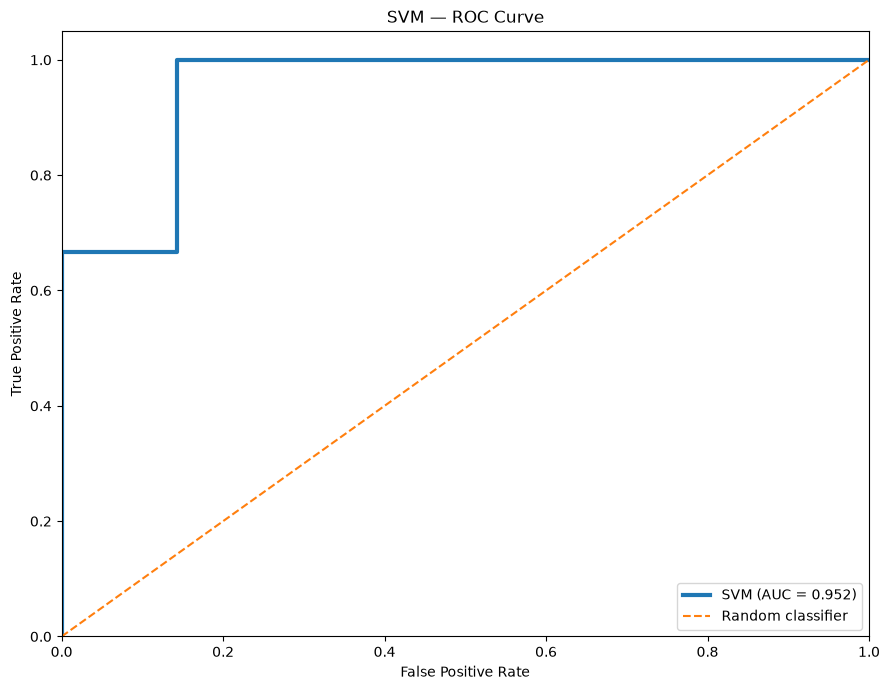

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"SVM (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM — ROC Curve")

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.legend(loc="lower right")
plt.grid(False)
plt.tight_layout()

plt.show()

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

In [28]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

In [31]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [32]:
cv_scores = cross_val_score(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print(cv_scores)

[0.63636364 0.72727273 0.8        0.8        0.9       ]


In [34]:
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("Mean CV accuracy:", cv_mean)
print("CV standard deviation:", cv_std)

Mean CV accuracy: 0.7727272727272727
CV standard deviation: 0.08757523330030763


In [36]:
model.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': 'deprecated',
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1]
}

In [39]:
grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [40]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

In [41]:
print("Best parameters:", grid_search.best_params_)

Best parameters: {'model__C': 10, 'model__gamma': 0.01}


In [42]:
print("Best CV accuracy:", grid_search.best_score_)

Best CV accuracy: 0.8109090909090909


In [43]:
best_model = grid_search.best_estimator_

In [44]:
y_pred_best = best_model.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score

best_accuracy = accuracy_score(y_test, y_pred_best)

print("Best SVM Model Test Accuracy:", best_accuracy)

Best SVM Model Test Accuracy: 0.7692307692307693


In [47]:
print("Actual:   ", y_test.to_numpy())
print("Best Model Predicted:", y_pred_best)

Actual:    ['A' 'C' 'C' 'A' 'C' 'A' 'C' 'A' 'A' 'C' 'A' 'C' 'A']
Best Model Predicted: ['A' 'C' 'C' 'C' 'C' 'C' 'C' 'A' 'A' 'C' 'A' 'C' 'C']


In [48]:
best_decision_scores = best_model.decision_function(X_test)

print(best_decision_scores)

[-1.89326301  1.46158159  0.97058232  0.57401517  0.99022876  0.1252786
  0.75662249 -1.22765774 -2.48460408  0.99762129 -0.84665397  1.00510402
  0.69060212]


In [49]:
best_auc = roc_auc_score(
    y_test,
    best_decision_scores
)

print("Best SVM Model ROC-AUC:", best_auc)

Best SVM Model ROC-AUC: 1.0


In [50]:
best_fpr, best_tpr, best_thresholds = roc_curve(
    y_test,
    best_decision_scores,
    pos_label="C"
)

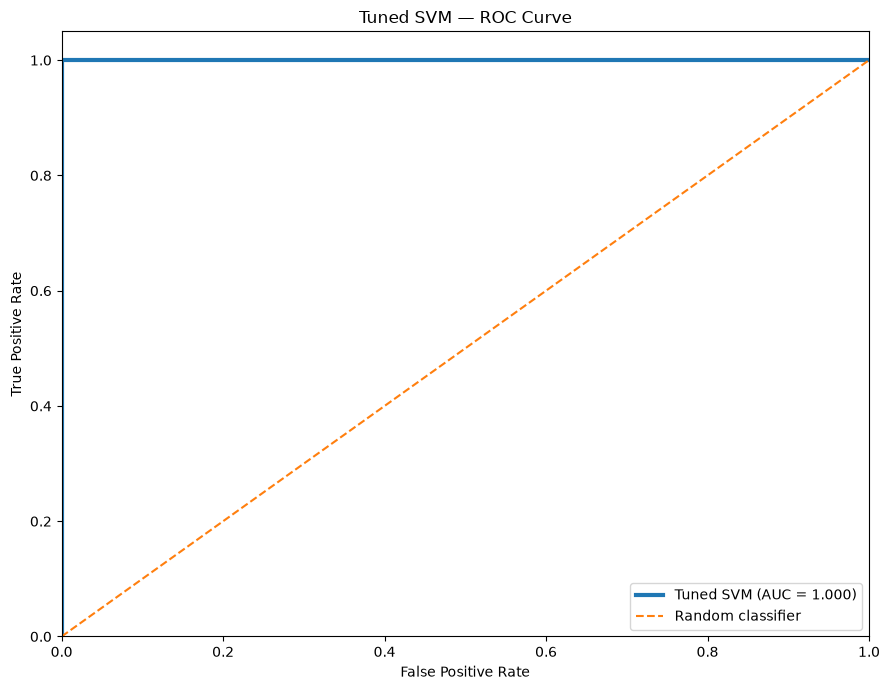

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.plot(
    best_fpr,
    best_tpr,
    linewidth=3,
    label=f"Tuned SVM (AUC = {best_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned SVM — ROC Curve")

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.legend(loc="lower right")
plt.grid(False)
plt.tight_layout()

plt.show()

In [52]:
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["AD", "CN"]
))

              precision    recall  f1-score   support

          AD       1.00      0.57      0.73         7
          CN       0.67      1.00      0.80         6

    accuracy                           0.77        13
   macro avg       0.83      0.79      0.76        13
weighted avg       0.85      0.77      0.76        13



In [53]:
svm_results = {
    "model": "SVM",
    "test_accuracy": best_accuracy,
    "roc_auc": best_auc,
    "cv_mean_accuracy": grid_search.best_score_,
    "cv_std_accuracy": grid_search.cv_results_["std_test_score"][grid_search.best_index_],
    "best_C": grid_search.best_params_["model__C"],
    "best_gamma": grid_search.best_params_["model__gamma"]
}

svm_results_df = pd.DataFrame([svm_results])

print(svm_results_df)

  model  test_accuracy  roc_auc  cv_mean_accuracy  cv_std_accuracy  best_C  \
0   SVM       0.769231      1.0          0.810909         0.077438      10   

   best_gamma  
0        0.01  


In [54]:
svm_results_df.to_csv(
    "../data/svm_results.csv",
    index=False
)

In [55]:
from pathlib import Path

Path("../figures/svm").mkdir(parents=True, exist_ok=True)

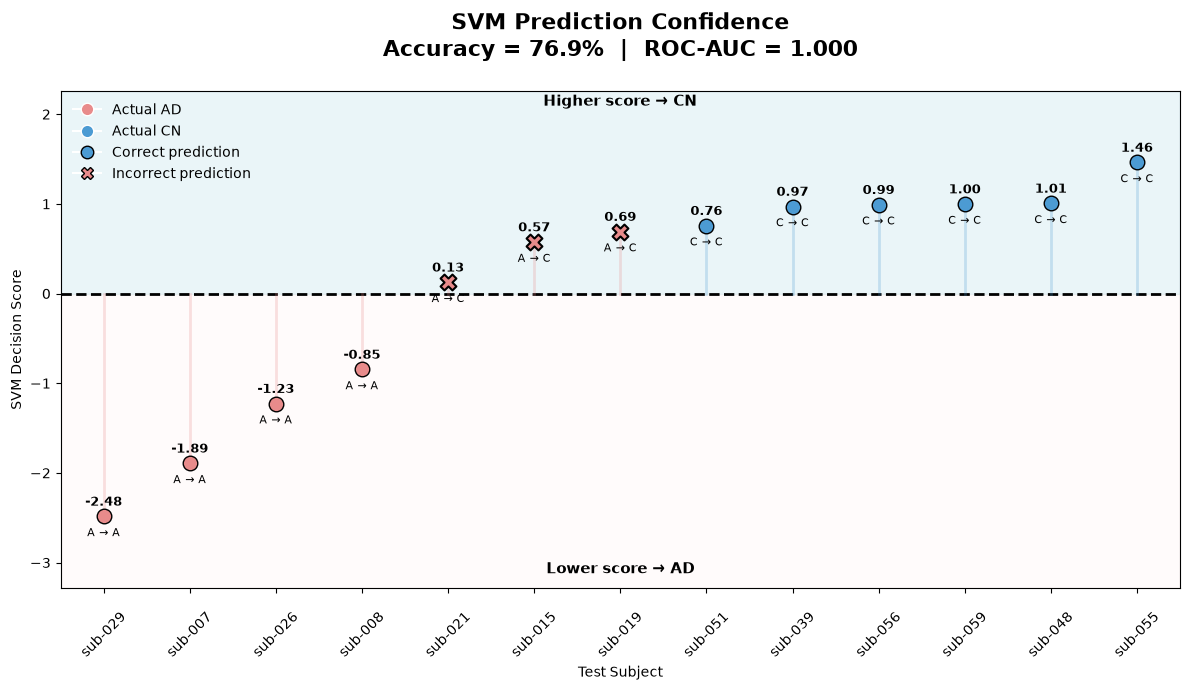

In [60]:
import matplotlib.pyplot as plt
import numpy as np

y_pred_from_score = np.where(best_decision_scores >= 0, "C", "A")

test_subjects = df.loc[y_test.index, "subject"].to_numpy()

order = np.argsort(best_decision_scores)

scores = best_decision_scores[order]
actual_groups = y_test.to_numpy()[order]
predicted_groups = y_pred_from_score[order]
subject_ids = test_subjects[order]

plt.figure(figsize=(12, 7))

plt.axhspan(
    0,
    scores.max() + 0.8,
    color="lightblue",
    alpha=0.25
)

plt.axhspan(
    scores.min() - 0.8,
    0,
    color="mistyrose",
    alpha=0.12
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Decision boundary = 0"
)

for i in range(len(scores)):

    score = scores[i]
    actual = actual_groups[i]
    predicted = predicted_groups[i]

    if actual == "A":
        point_color = "#E88B8B"
    else:
        point_color = "#4C9BD3"

    correct = actual == predicted

    plt.plot(
        [i + 1, i + 1],
        [0, score],
        color=point_color,
        alpha=0.25,
        linewidth=2
    )

    if correct:
        plt.scatter(
            i + 1,
            score,
            s=110,
            color=point_color,
            edgecolors="black",
            linewidths=1,
            marker="o",
            zorder=3
        )
    else:
        plt.scatter(
            i + 1,
            score,
            s=130,
            color=point_color,
            edgecolors="black",
            linewidths=1.5,
            marker="X",
            zorder=4
        )

    plt.text(
        i + 1,
        score + 0.12,
        f"{score:.2f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    plt.text(
        i + 1,
        score - 0.22,
        f"{actual} → {predicted}",
        ha="center",
        fontsize=8
    )

plt.xticks(
    range(1, len(subject_ids) + 1),
    subject_ids,
    rotation=45
)

plt.tick_params(
    axis="x",
    pad=12
)

plt.subplots_adjust(bottom=0.3)

plt.xlabel("Test Subject")
plt.ylabel("SVM Decision Score")

plt.title(
    f"SVM Prediction Confidence\n"
    f"Accuracy = {best_accuracy:.1%}  |  ROC-AUC = {best_auc:.3f}",
    fontsize=16,
    fontweight="bold",
    pad=25
)

plt.text(
    0.5,
    0.97,
    "Higher score → CN",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.text(
    0.5,
    0.03,
    "Lower score → AD",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

correct_legend = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#4C9BD3",
    markeredgecolor="black",
    markersize=9,
    label="Correct prediction"
)

wrong_legend = plt.Line2D(
    [0],
    [0],
    marker="X",
    color="w",
    markerfacecolor="#E88B8B",
    markeredgecolor="black",
    markersize=9,
    label="Incorrect prediction"
)

actual_ad = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#E88B8B",
    markersize=9,
    label="Actual AD"
)

actual_cn = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#4C9BD3",
    markersize=9,
    label="Actual CN"
)

plt.legend(
    handles=[
        actual_ad,
        actual_cn,
        correct_legend,
        wrong_legend
    ],
    loc="upper left",
    frameon=False
)

plt.xlim(
    0.5,
    len(subject_ids) + 0.5
)

plt.ylim(
    scores.min() - 0.8,
    scores.max() + 0.8
)

plt.grid(False)
plt.tight_layout()

plt.savefig(
    "../figures/svm/prediction_confidence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

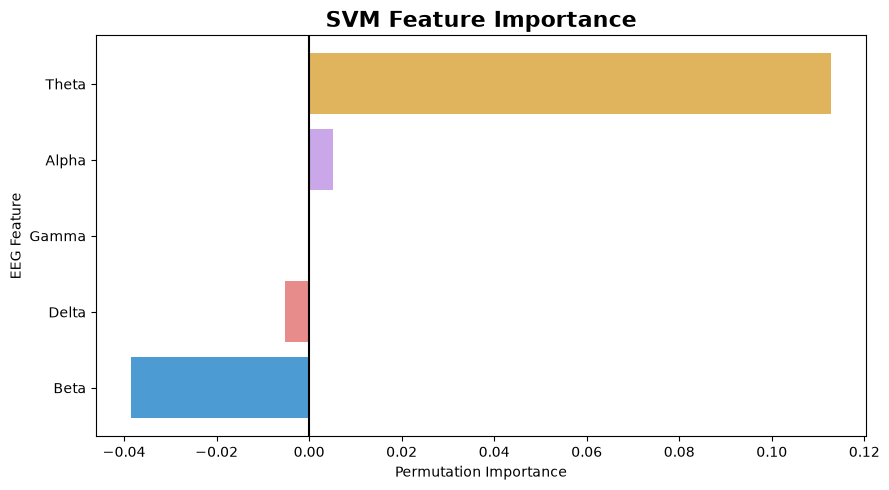

In [62]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="accuracy",
    n_repeats=30,
    random_state=42
)

feature_importance = pd.DataFrame({
    "Feature": ["Delta", "Theta", "Alpha", "Beta", "Gamma"],
    "Importance": result.importances_mean
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color=["#4C9BD3", "#E88B8B", "#8CCB8C", "#C9A7E8", "#E0B45C"]
)

plt.axvline(
    0,
    color="black",
    linewidth=1.5
)

plt.xlabel("Permutation Importance")
plt.ylabel("EEG Feature")
plt.title(
    "SVM Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.grid(False)
plt.tight_layout()

plt.savefig(
    "../figures/svm/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

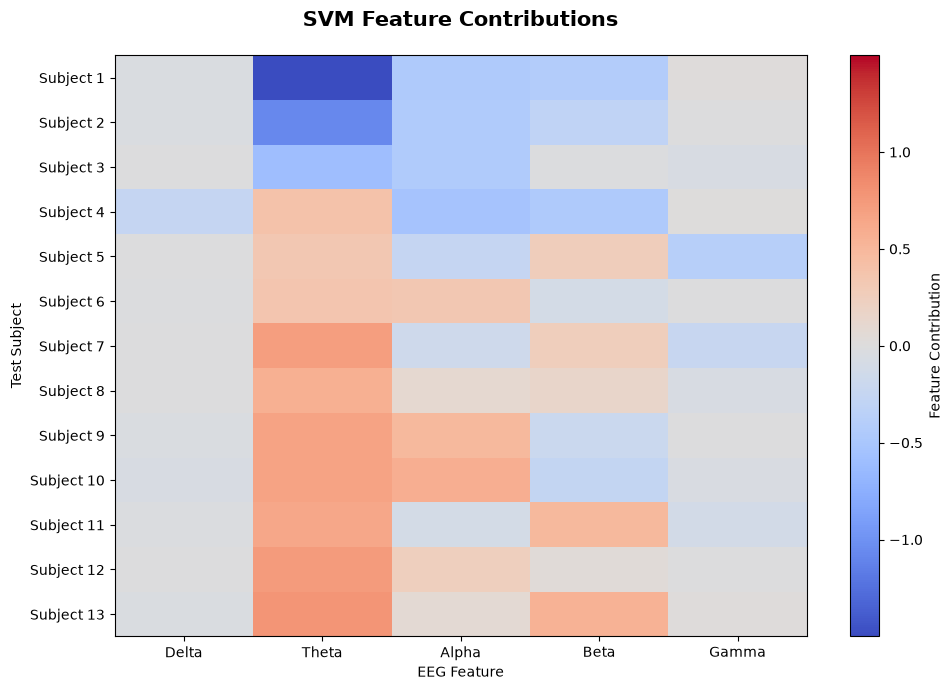

In [66]:
import matplotlib.pyplot as plt
import numpy as np

features = ["delta", "theta", "alpha", "beta", "gamma"]

baseline_scores = best_model.decision_function(X_test)

contributions = np.zeros(
    (len(X_test), len(features))
)

for j, feature in enumerate(features):

    X_test_modified = X_test.copy()

    X_test_modified[feature] = X_train[feature].mean()

    modified_scores = best_model.decision_function(
        X_test_modified
    )

    contributions[:, j] = (
        baseline_scores - modified_scores
    )

order = np.argsort(baseline_scores)

contributions_sorted = contributions[order]

plt.figure(figsize=(10, 7))

max_value = np.max(np.abs(contributions_sorted))

plt.imshow(
    contributions_sorted,
    aspect="auto",
    cmap="coolwarm",
    vmin=-max_value,
    vmax=max_value
)

plt.colorbar(
    label="Feature Contribution"
)

plt.xticks(
    range(len(features)),
    ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
)

plt.yticks(
    range(len(order)),
    [f"Subject {i + 1}" for i in range(len(order))]
)

plt.xlabel("EEG Feature")
plt.ylabel("Test Subject")

plt.title(
    "SVM Feature Contributions",
    fontsize=15,
    fontweight="bold",
    pad=21
)

plt.tight_layout()

plt.savefig(
    "../figures/svm/feature_contributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

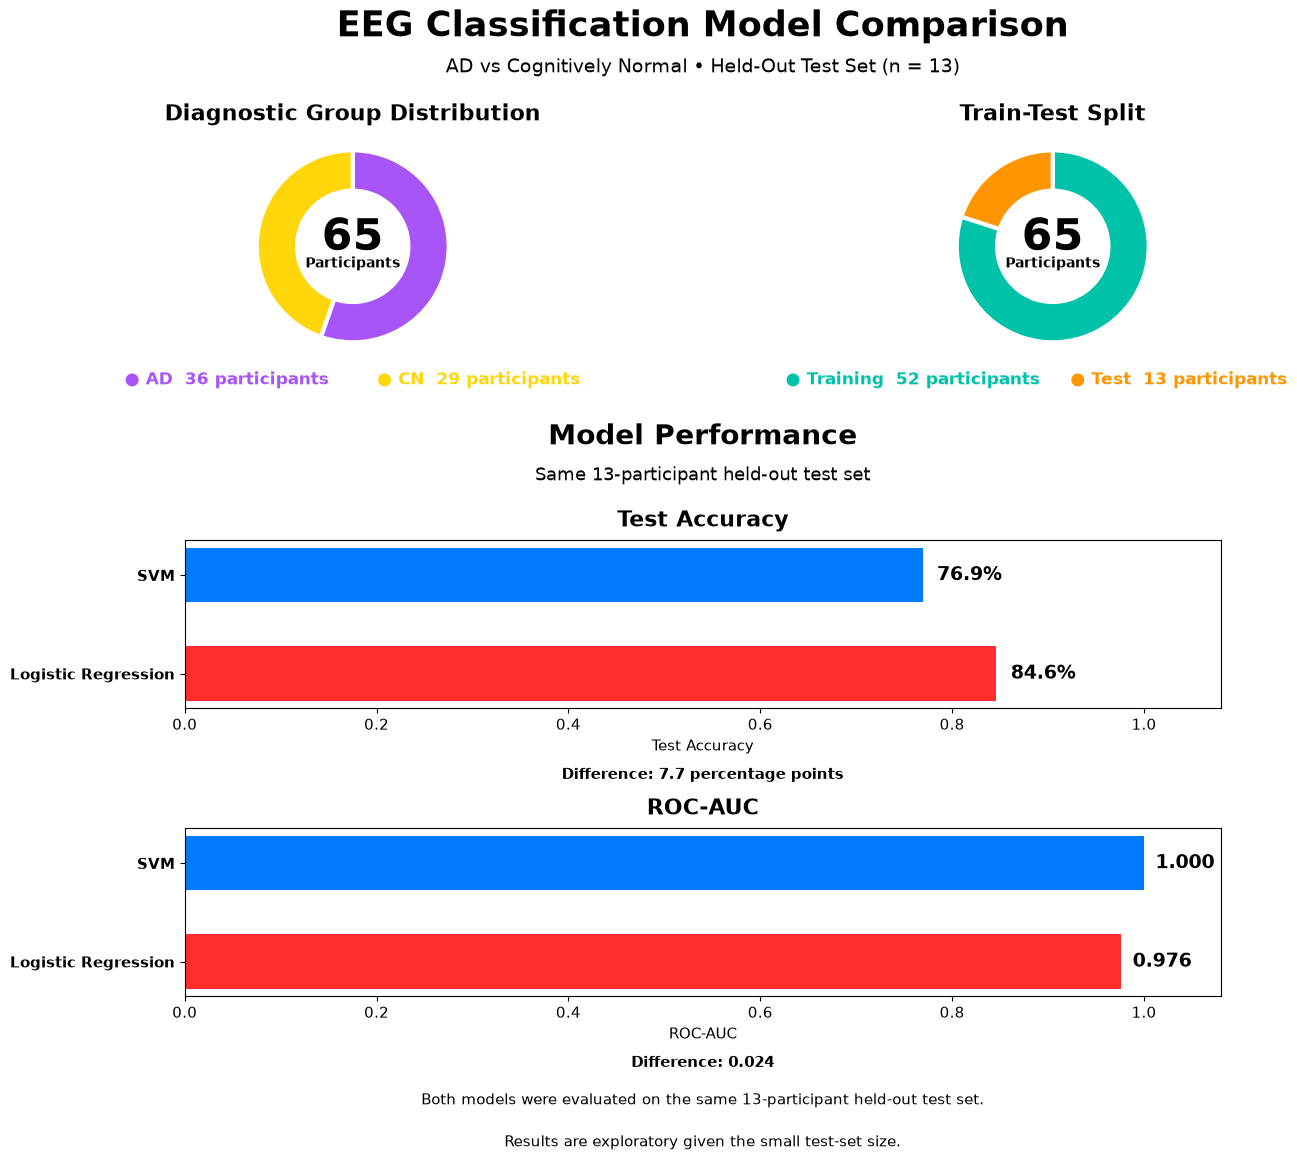

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

logistic_results = pd.read_csv(
    "../data/logistic_regression_results.csv"
)

svm_results = pd.read_csv(
    "../data/svm_results.csv"
)

logistic_accuracy = logistic_results.loc[0, "test_accuracy"]
logistic_auc = logistic_results.loc[0, "roc_auc"]

svm_accuracy = svm_results.loc[0, "test_accuracy"]
svm_auc = svm_results.loc[0, "roc_auc"]

logistic_color = "#FF2D2D"
svm_color = "#007AFF"

diagnostic_ad_color = "#A855F7"
diagnostic_cn_color = "#FFD60A"

train_color = "#00C2A8"
test_color = "#FF9500"

fig = plt.figure(figsize=(14, 12))
fig.patch.set_facecolor("white")

fig.text(
    0.5,
    0.965,
    "EEG Classification Model Comparison",
    ha="center",
    fontsize=25,
    fontweight="bold"
)

fig.text(
    0.5,
    0.935,
    "AD vs Cognitively Normal • Held-Out Test Set (n = 13)",
    ha="center",
    fontsize=14
)

fig.text(
    0.25,
    0.895,
    "Diagnostic Group Distribution",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.75,
    0.895,
    "Train-Test Split",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

left_ax = fig.add_axes(
    [0.06, 0.690, 0.38, 0.20]
)

left_ax.set_aspect("equal")
left_ax.axis("off")

left_ax.pie(
    [36, 29],
    colors=[
        diagnostic_ad_color,
        diagnostic_cn_color
    ],
    startangle=90,
    counterclock=False,
    radius=1.0,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white",
        "linewidth": 3
    }
)

left_ax.text(
    0,
    0.08,
    "65",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

left_ax.text(
    0,
    -0.18,
    "Participants",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

fig.text(
    0.16,
    0.675,
    "● AD  36 participants",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=diagnostic_ad_color
)

fig.text(
    0.34,
    0.675,
    "● CN  29 participants",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=diagnostic_cn_color
)

right_ax = fig.add_axes(
    [0.56, 0.690, 0.38, 0.20]
)

right_ax.set_aspect("equal")
right_ax.axis("off")

right_ax.pie(
    [52, 13],
    colors=[
        train_color,
        test_color
    ],
    startangle=90,
    counterclock=False,
    radius=1.0,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white",
        "linewidth": 3
    }
)

right_ax.text(
    0,
    0.08,
    "65",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

right_ax.text(
    0,
    -0.18,
    "Participants",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

fig.text(
    0.65,
    0.675,
    "● Training  52 participants",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=train_color
)

fig.text(
    0.84,
    0.675,
    "● Test  13 participants",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=test_color
)

fig.text(
    0.5,
    0.625,
    "Model Performance",
    ha="center",
    fontsize=20,
    fontweight="bold"
)

fig.text(
    0.5,
    0.595,
    "Same 13-participant held-out test set",
    ha="center",
    fontsize=13
)

accuracy_ax = fig.add_axes(
    [0.13, 0.405, 0.74, 0.14]
)

accuracy_models = [
    "Logistic Regression",
    "SVM"
]

accuracy_values = [
    logistic_accuracy,
    svm_accuracy
]

accuracy_colors = [
    logistic_color,
    svm_color
]

accuracy_ax.barh(
    accuracy_models,
    accuracy_values,
    color=accuracy_colors,
    height=0.55,
)

accuracy_ax.set_xlim(0, 1.08)

accuracy_ax.set_xlabel(
    "Test Accuracy",
    fontsize=11
)

accuracy_ax.set_title(
    "Test Accuracy",
    fontsize=16,
    fontweight="bold",
    pad=10
)

accuracy_ax.tick_params(
    axis="both",
    labelsize=11
)

for label in accuracy_ax.get_yticklabels():
    label.set_fontweight("bold")

accuracy_ax.grid(False)

for i, value in enumerate(accuracy_values):

    accuracy_ax.text(
        value + 0.015,
        i,
        f"{value * 100:.1f}%",
        va="center",
        fontsize=14,
        fontweight="bold"
    )

accuracy_difference = abs(
    logistic_accuracy - svm_accuracy
)

accuracy_ax.text(
    0.5,
    -0.42,
    f"Difference: {accuracy_difference * 100:.1f} percentage points",
    transform=accuracy_ax.transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

auc_ax = fig.add_axes(
    [0.13, 0.165, 0.74, 0.14]
)

auc_values = [
    logistic_auc,
    svm_auc
]

auc_ax.barh(
    accuracy_models,
    auc_values,
    color=accuracy_colors,
    height=0.55
)

auc_ax.set_xlim(0, 1.08)

auc_ax.set_xlabel(
    "ROC-AUC",
    fontsize=11
)

auc_ax.set_title(
    "ROC-AUC",
    fontsize=16,
    fontweight="bold",
    pad=10
)

auc_ax.tick_params(
    axis="both",
    labelsize=11
)

for label in auc_ax.get_yticklabels():
    label.set_fontweight("bold")

auc_ax.grid(False)

for i, value in enumerate(auc_values):

    auc_ax.text(
        value + 0.012,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=14,
        fontweight="bold"
    )

auc_difference = abs(
    logistic_auc - svm_auc
)

auc_ax.text(
    0.5,
    -0.42,
    f"Difference: {auc_difference:.3f}",
    transform=auc_ax.transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

fig.text(
    0.5,
    0.075,
    "Both models were evaluated on the same 13-participant held-out test set.",
    ha="center",
    fontsize=11
)

fig.text(
    0.5,
    0.04,
    "Results are exploratory given the small test-set size.",
    ha="center",
    fontsize=11
)

from pathlib import Path

Path("../figures/model_comparison").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "../figures/model_comparison/logistic_regression_vs_svm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Support Vector Machine — Detailed Summary and Experimental Record

## 1. Purpose

This notebook applies a **Support Vector Machine (SVM)** classifier to subject-level EEG spectral features for binary classification of:

**Alzheimer's disease (AD) vs Cognitively normal (CN)**

Participants diagnosed with Frontotemporal Dementia (FTD) were excluded from this experiment.

---

## 2. Input Dataset

The input dataset was the subject-level feature table generated from the complete OpenNeuro `ds004504` dataset.

The classification dataset contained:

**65 participants**

| Group | Subjects |
|---|---:|
| Alzheimer's disease (AD) | 36 |
| Cognitively normal (CN) | 29 |
| **Total** | **65** |

Each participant was represented using five EEG spectral features:

- Delta relative power
- Theta relative power
- Alpha relative power
- Beta relative power
- Gamma relative power

---

## 3. Train-Test Split

The 65 participants were divided using a stratified 80/20 train-test split:

- **52 participants** for training
- **13 participants** for the held-out test set

The 13-participant test set was kept separate from cross-validation and hyperparameter selection.

---

## 4. Feature Scaling

The five EEG features were standardized using `StandardScaler`.

The scaler was fitted using the training data and then applied to the training and test data.

For cross-validation and hyperparameter tuning, scaling was included inside an SVM `Pipeline` so that scaling was performed independently within each training fold.

---

## 5. Initial SVM Model

The initial SVM classifier was created using:

```python
SVC()
```

The default configuration used:

- **Kernel:** RBF
- **C:** 1.0
- **Gamma:** `scale`

The RBF kernel allows the SVM to model nonlinear decision boundaries.

---

## 6. Initial SVM Test Results

The initial SVM was evaluated on the held-out test set of 13 participants.

**Test accuracy: 76.9%**

The confusion matrix was:

```text
                 Predicted
                 AD    CN

Actual AD         4     3
Actual CN         0     6
```

This corresponds to:

- **4 AD participants** correctly classified as AD
- **3 AD participants** classified as CN
- **6 CN participants** correctly classified as CN
- **0 CN participants** classified as AD

---

## 7. Initial Classification Metrics

The initial SVM classification report was:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| AD | 1.00 | 0.57 | 0.73 | 7 |
| CN | 0.67 | 1.00 | 0.80 | 6 |

Overall accuracy was:

**76.9%**

---

## 8. Initial ROC-AUC

The initial SVM produced a ROC-AUC of:

**0.952**

The ROC curve was generated using SVM decision scores rather than probability estimates.

---

## 9. Initial Cross-Validation

A 5-fold stratified cross-validation procedure was applied to the **52 training participants**.

The initial SVM cross-validation scores were:

```text
0.636
0.727
0.800
0.800
0.900
```

The mean cross-validation accuracy was:

**77.3%**

The standard deviation was:

**8.8%**

The 13-participant held-out test set was not included in this cross-validation.

---

## 10. Hyperparameter Tuning

`GridSearchCV` was used to evaluate different combinations of the SVM hyperparameters:

- `C`
- `gamma`

The search tested:

- `C`: 0.1, 1, 10, 100
- `gamma`: `scale`, 0.01, 0.1, 1

This produced **16 parameter combinations**, each evaluated using 5-fold stratified cross-validation on the 52 training participants.

### Best Parameters

The best parameter combination was:

```text
C = 10
gamma = 0.01
```

The corresponding best mean cross-validation accuracy was:

**81.1%**

The standard deviation for the selected parameter combination was:

**7.7%**

---

## 11. Tuned SVM Test Results

The tuned SVM was then evaluated on the same untouched 13-participant test set.

**Test accuracy: 76.9%**

The tuned model produced the same class predictions as the initial SVM on the held-out test set.

Therefore:

**10 of 13 test participants were correctly classified.**

---

## 12. Tuned SVM Classification Metrics

The tuned SVM classification report was:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| AD | 1.00 | 0.57 | 0.73 | 7 |
| CN | 0.67 | 1.00 | 0.80 | 6 |

The classification metrics remained unchanged because the final test-set predictions did not change after hyperparameter tuning.

---

## 13. Tuned SVM ROC-AUC

The tuned SVM produced:

**ROC-AUC: 1.000**

on the 13-participant held-out test set.

The ROC curve was generated.

> This reflects the ranking of the SVM decision scores on this particular test set and should not be interpreted as evidence of perfect generalization, particularly given the small test-set size.

---

## 14. Final SVM Results

| Metric | Result |
|---|---:|
| Test Accuracy | **76.9%** |
| ROC-AUC | **1.000** |
| Best CV Accuracy | **81.1%** |
| Best CV Standard Deviation | **7.7%** |
| Best `C` | **10** |
| Best `gamma` | **0.01** |

---

## 15. Interpretation

The SVM learned a nonlinear classification boundary using the five subject-level EEG spectral features.

Hyperparameter tuning increased the mean cross-validation accuracy from the initial SVM configuration to **81.1%**, but the final predictions on the untouched 13-participant test set remained unchanged.

The test accuracy therefore remained:

**76.9%**

The tuned SVM produced a ROC-AUC of **1.000** on the same 13-participant test set. Because the test set is small, these results should be interpreted as an experimental evaluation rather than as evidence of clinical diagnostic performance or perfect generalization.

---

## 16. Model Visualizations

The SVM analysis includes the following visualizations:

### 🔎 Prediction Confidence

Provides a detailed subject-level visualization showing the actual class, predicted class, decision score, decision boundary, and correct versus incorrect predictions.

### 🎯 Feature Importance

Shows how much the model's accuracy changes when each EEG feature is randomly shuffled.
Higher importance indicates that the SVM relied more on that feature for its predictions.

### 🧬 Feature Contributions

Visualizes the change in SVM decision score associated with replacing individual test-set features with their corresponding training-set means.

Because the model uses an RBF kernel, these values should not be interpreted as Logistic Regression-style coefficients.

### 📊 Logistic Regression vs SVM Comparison

A comparison visualization was created using the saved results from both models and compares their:

- Test Accuracy
- ROC-AUC

Both models were evaluated on the same 13-participant held-out test set.

---

## 17. Saved Figures

The SVM figures are organized under:

`figures/svm/`

Currently saved:

- `prediction_confidence.png`
- `feature_importance.png`
- `feature_contributions.png`

The Logistic Regression vs SVM comparison figure is saved under:

`figures/model_comparison/logistic_regression_vs_svm.png`

The ROC curve was generated during the SVM analysis but was not saved as a figure for this milestone.

---

## 18. Data Leakage Considerations

A major consideration in EEG machine learning is that multiple epochs can originate from the same participant.

The final 13-participant test set was therefore kept completely separate during cross-validation and hyperparameter tuning.

Cross-validation and parameter selection were performed only on the 52 training participants.

The scaling step was included inside the SVM pipeline during cross-validation so that scaling parameters were learned independently within each training fold.

This prevents information from the held-out test set from influencing model selection.

---

## 19. Output

The final SVM results were saved locally as:

`data/svm_results.csv`

The results file contains:

- Model name
- Test accuracy
- ROC-AUC
- Cross-validation mean accuracy
- Cross-validation standard deviation
- Best `C`
- Best `gamma`

---

## 20. Reproducibility

The train-test split and cross-validation use fixed random states for reproducibility.

The SVM pipeline, hyperparameter search space, evaluation metrics, and final results are documented in this notebook.

---

## 21. Next Step

The next machine-learning experiment will evaluate a **Random Forest** classifier using the same subject-level EEG feature dataset and a consistent evaluation framework.